# ResNet18 From Scratch / Non-Pretrained

Purpose: collect the non-pretrained ResNet18 runs in one notebook. These runs use the ResNet18 architecture with `weights=None` and all layers trainable.

The scratch runs are diagnostic comparisons against the pretrained ResNet18 runs, not the first-choice deployment model.

In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent

master_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.csv'
summary_path = ROOT / 'reports' / 'model_comparison' / 'model_results_master.json'
if not master_path.exists() or not summary_path.exists():
    display(Markdown("**Model results summary not found. Rebuilding from local metric artifacts...**"))
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)

master = pd.read_csv(master_path)
summary = json.loads(summary_path.read_text(encoding='utf-8'))

metric_cols = [
    'model_name', 'run_group', 'pretrained', 'seed', 'split',
    'accuracy', 'precision_macro', 'recall_macro', 'f1_macro',
    'best_epoch', 'epochs_trained', 'recommendation', 'notes'
]

loaded_rows = master[master['status'] == 'loaded'].copy()
missing_rows = master[master['status'] != 'loaded'].copy()
if missing_rows.empty:
    display(Markdown(f"**Artifact status:** all `{len(master)}` result rows loaded from local metrics."))
else:
    display(Markdown(
        f"**Artifact status:** `{len(loaded_rows)}` loaded, `{len(missing_rows)}` missing. "
        "Missing rows mean the ignored metric/checkpoint artifacts are not present locally. "
        "Run the reproduction commands in this notebook, then rerun `python -m src.evaluation.build_model_results_master`."
    ))
    display(missing_rows[['model_family', 'run_group', 'seed', 'status', 'metrics_file']].head(20))

def rebuild_master_results():
    """Rebuild reports/model_comparison from whatever metric artifacts exist locally."""
    subprocess.run([sys.executable, '-m', 'src.evaluation.build_model_results_master'], cwd=ROOT, check=True)
    return pd.read_csv(master_path)

**Artifact status:** `12` loaded, `6` missing. Missing rows mean the ignored metric/checkpoint artifacts are not present locally. Run the reproduction commands in this notebook, then rerun `python -m src.evaluation.build_model_results_master`.

,model_family,run_group,seed,status,metrics_file
12,convnextv2_tiny,convnextv2_pretrained_linear_probe,NaN,missing,model/convnextv2_tiny_fcmae_ft_in1k_linear_pro...
13,convnextv2_tiny,convnextv2_pretrained_linear_probe,123.0,missing,model/convnextv2_tiny_fcmae_ft_in1k_linear_pro...
14,convnextv2_tiny,convnextv2_pretrained_finetune_suspect,NaN,missing,model/convnextv2_tiny_fcmae_ft_in1k_finetune/b...
15,convnextv2_tiny,convnextv2_scratch_50ep_early_stopped_strict,42.0,missing,reports/convnextv2_scratch/convnextv2_tiny_scr...
16,convnextv2_tiny,convnextv2_scratch_50ep_early_stopped_strict,123.0,missing,reports/convnextv2_scratch/convnextv2_tiny_scr...
17,convnextv2_tiny,convnextv2_scratch_50ep_early_stopped_strict,999.0,missing,reports/convnextv2_scratch/convnextv2_tiny_scr...


In [2]:
def show_existing_figures(rows):
    for _, row in rows.iterrows():
        title = f"{row['run_group']} seed={row['seed']}"
        print(title)
        for column in ['confusion_matrix_figure', 'training_curve_figure']:
            value = row.get(column)
            if isinstance(value, str) and value:
                path = ROOT / value
                if path.exists():
                    display(Image(filename=str(path)))

In [3]:
resnet_scratch = master[(master['model_family'] == 'resnet18') & (master['pretrained'] == False)].copy()
resnet_scratch[metric_cols].sort_values(['run_group', 'seed'])

,model_name,run_group,pretrained,seed,split,accuracy,precision_macro,recall_macro,f1_macro,best_epoch,epochs_trained,recommendation,notes
4,ResNet18 from scratch strict split,resnet18_scratch_20ep_strict,False,42.0,strict contiguous split seed 42,0.996429,0.996454,0.996429,0.996429,18.0,20.0,diagnostic scratch comparison,20-epoch scratch run used to compare against p...
7,ResNet18 from scratch strict split,resnet18_scratch_20ep_strict,False,123.0,strict contiguous split seed 123,0.991071,0.991071,0.991071,0.991071,16.0,20.0,diagnostic scratch comparison,20-epoch scratch run used to compare against p...
10,ResNet18 from scratch strict split,resnet18_scratch_20ep_strict,False,999.0,strict contiguous split seed 999,0.998214,0.998227,0.998214,0.998214,12.0,20.0,diagnostic scratch comparison,20-epoch scratch run used to compare against p...
5,ResNet18 from scratch 50ep early-stopped stric...,resnet18_scratch_50ep_early_stopped_strict,False,42.0,strict contiguous split seed 42,0.994643,0.994706,0.994643,0.994643,18.0,28.0,preferred scratch diagnostic,50-epoch maximum scratch run with early stoppi...
8,ResNet18 from scratch 50ep early-stopped stric...,resnet18_scratch_50ep_early_stopped_strict,False,123.0,strict contiguous split seed 123,0.982143,0.982503,0.982143,0.982099,3.0,20.0,preferred scratch diagnostic,50-epoch maximum scratch run with early stoppi...
11,ResNet18 from scratch 50ep early-stopped stric...,resnet18_scratch_50ep_early_stopped_strict,False,999.0,strict contiguous split seed 999,0.991071,0.991244,0.991071,0.991090,12.0,22.0,preferred scratch diagnostic,50-epoch maximum scratch run with early stoppi...


In [4]:
comparison_groups = [
    'resnet18_pretrained_finetune_last_block_strict',
    'resnet18_scratch_20ep_strict',
    'resnet18_scratch_50ep_early_stopped_strict',
]
comparison = master[master['run_group'].isin(comparison_groups)].copy()
comparison.groupby('run_group').agg(
    runs=('accuracy', 'count'),
    mean_accuracy=('accuracy', 'mean'),
    min_accuracy=('accuracy', 'min'),
    max_accuracy=('accuracy', 'max'),
    mean_f1=('f1_macro', 'mean'),
).reset_index()

,run_group,runs,mean_accuracy,min_accuracy,max_accuracy,mean_f1
0,resnet18_pretrained_finetune_last_block_strict,3,0.997619,0.992857,1.000000,0.997610
1,resnet18_scratch_20ep_strict,3,0.995238,0.991071,0.998214,0.995238
2,resnet18_scratch_50ep_early_stopped_strict,3,0.989286,0.982143,0.994643,0.989277


resnet18_scratch_50ep_early_stopped_strict seed=42.0


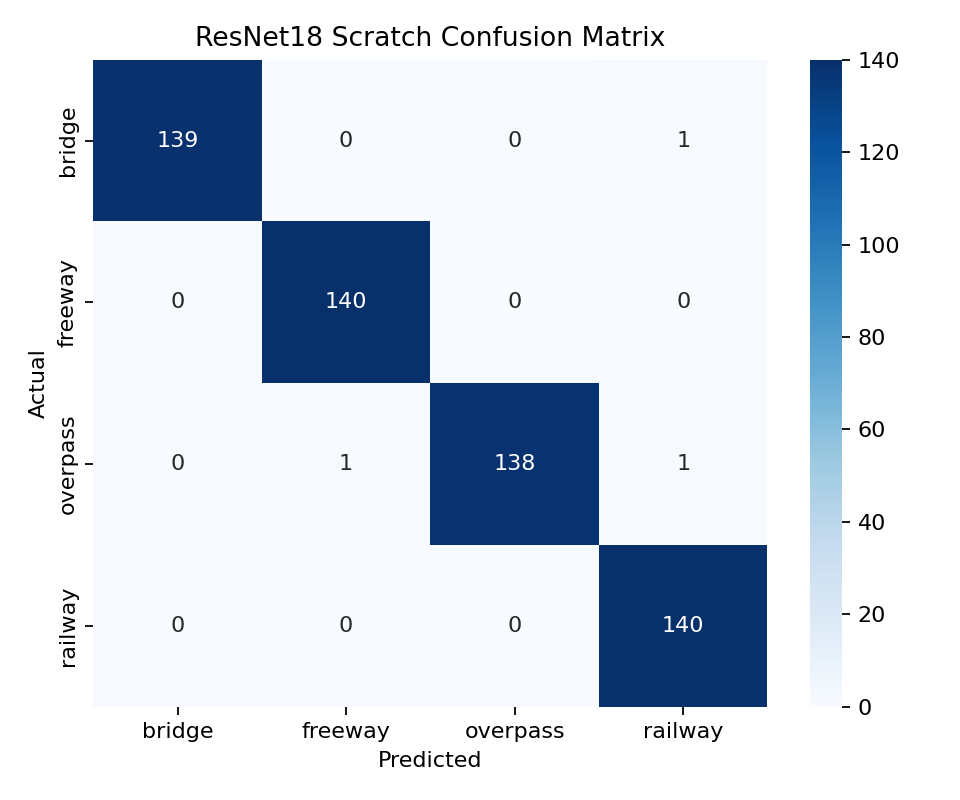

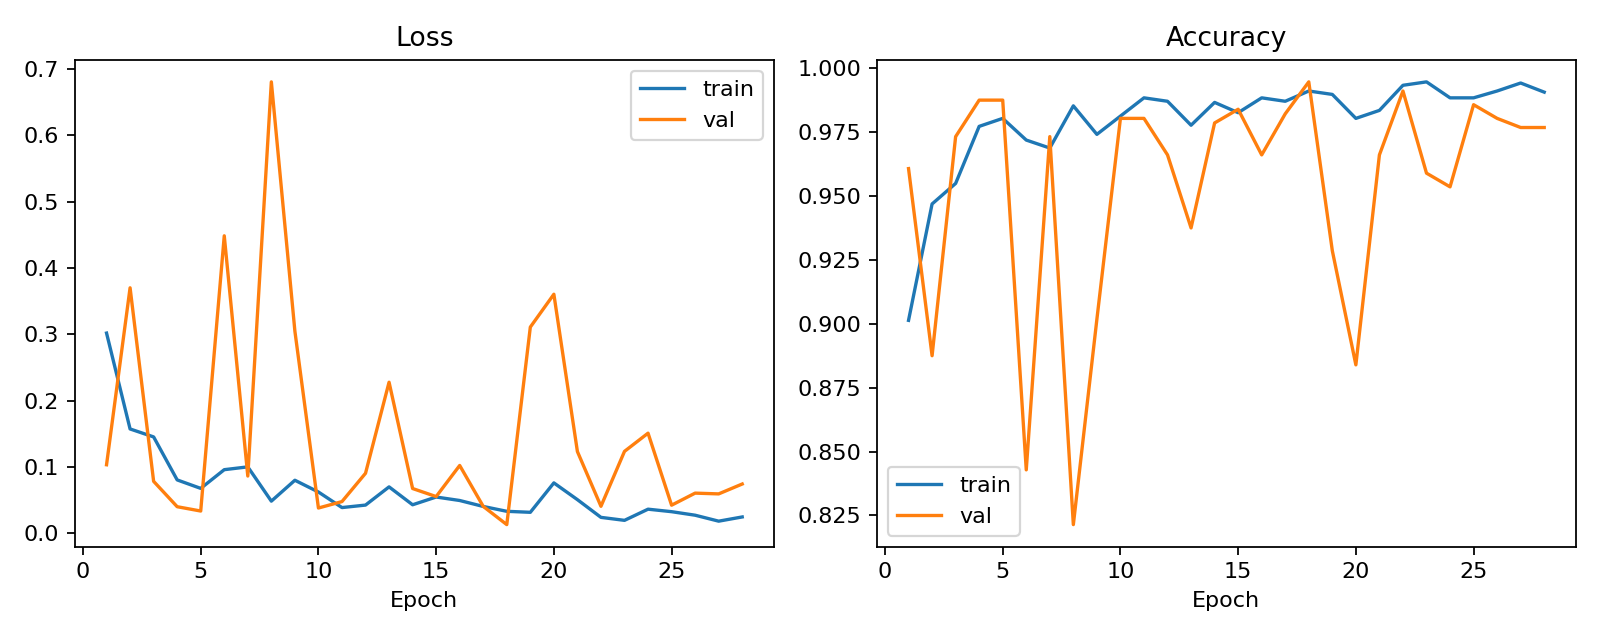

resnet18_scratch_50ep_early_stopped_strict seed=123.0


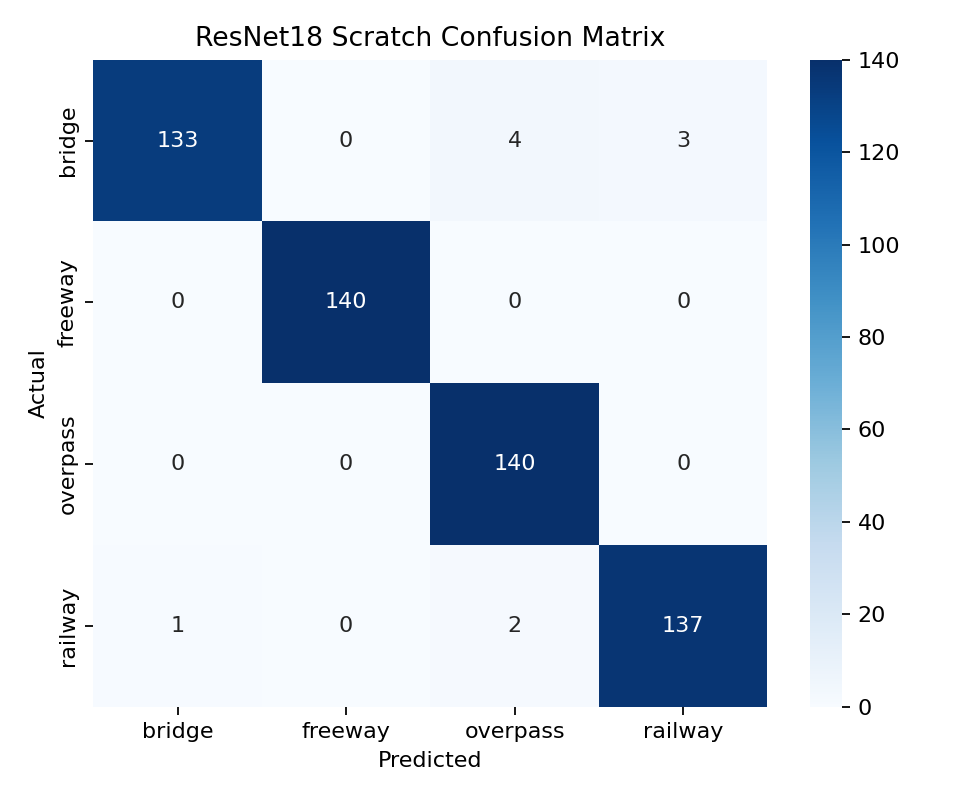

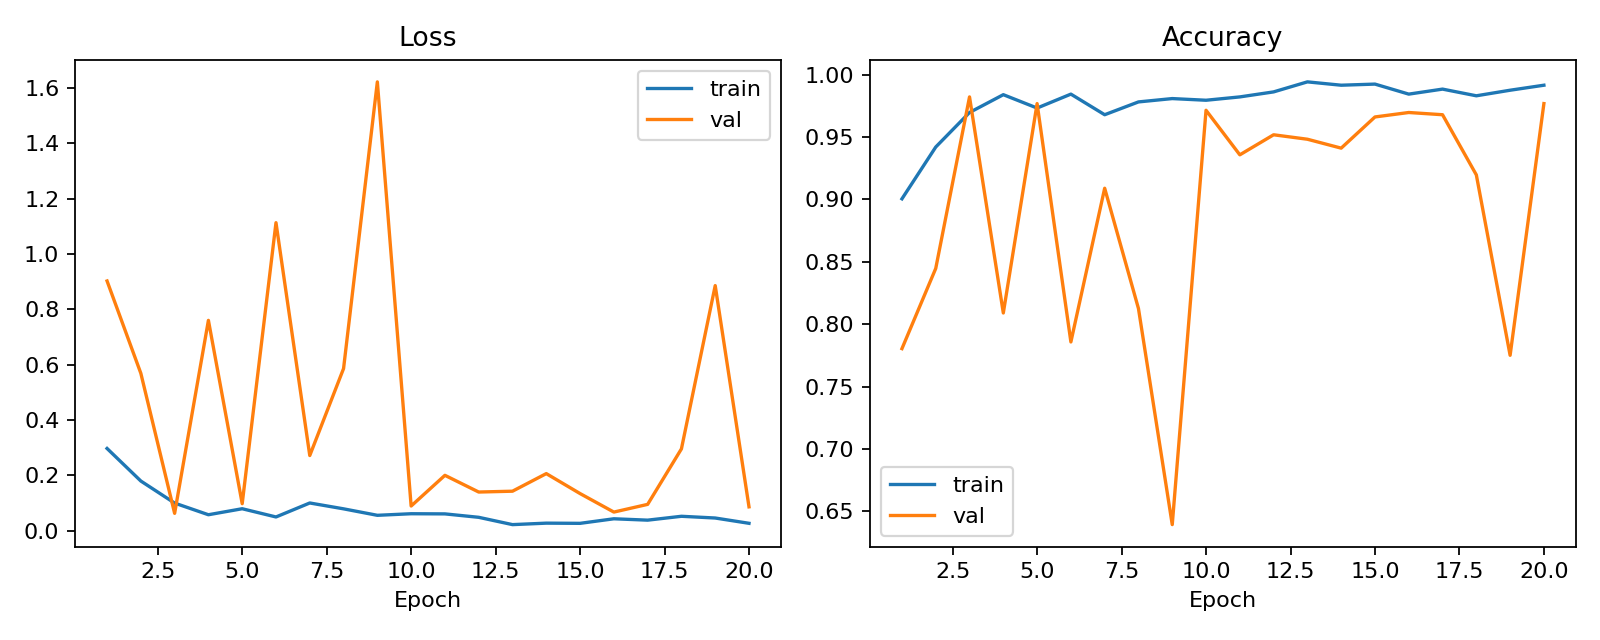

resnet18_scratch_50ep_early_stopped_strict seed=999.0


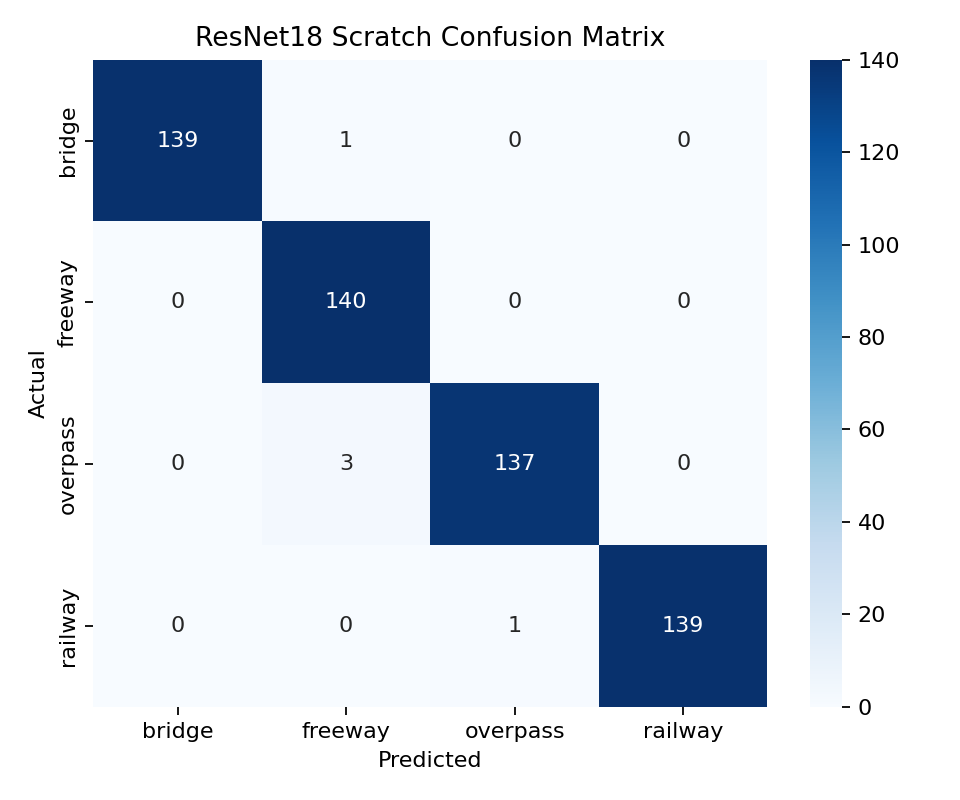

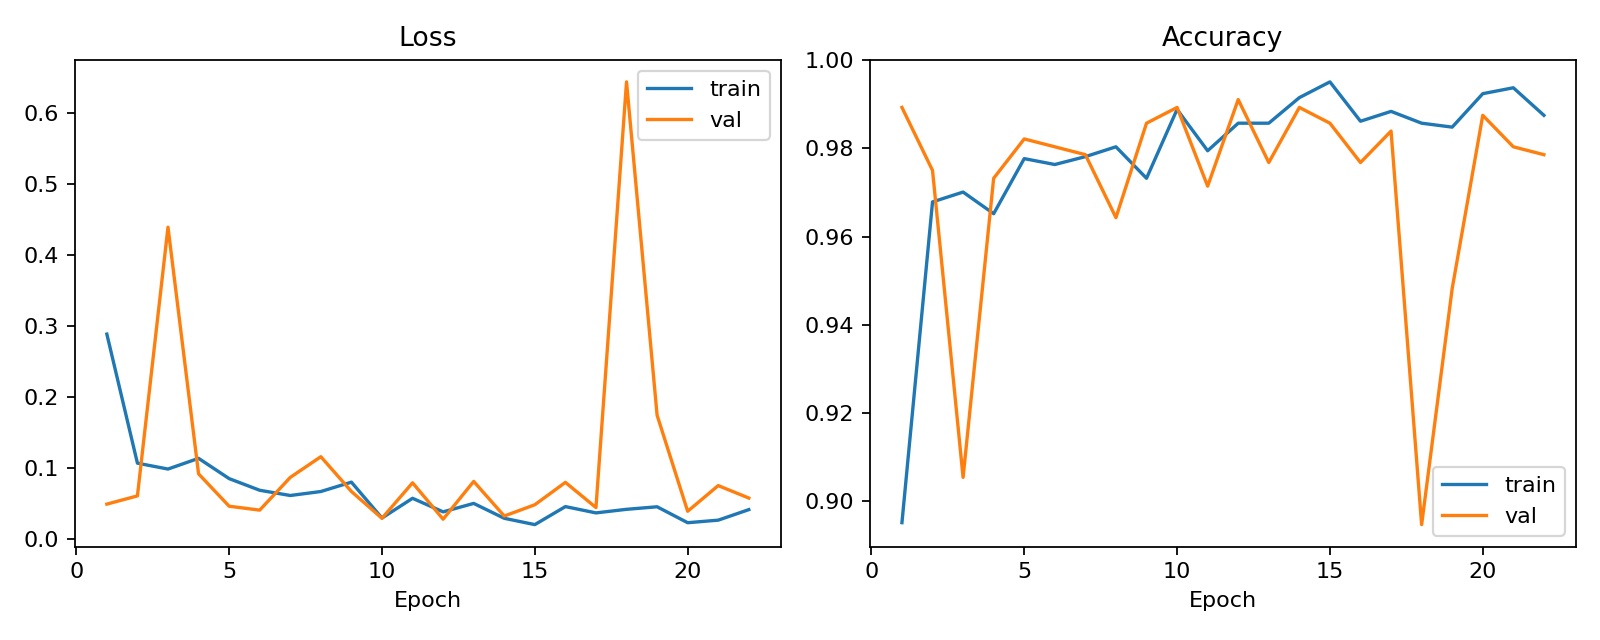

In [5]:
preferred = resnet_scratch[resnet_scratch['run_group'] == 'resnet18_scratch_50ep_early_stopped_strict']
show_existing_figures(preferred)